# OPOR Go-Live 2 Command Centre Intelligence System
## Notebook 1: Data Processing & Exploratory Data Analysis

**Author:** Siddharajsinh (Sid)

**Project Goal:** Analyze healthcare system go-live support incidents to identify
patterns, understand issue distribution, and prepare data for machine learning.

**Context:** Nova Scotia Health (NSH) is rolling out One Person One Record (OPOR).
IWK Health completed Go-Live 1 on December 6, 2025.
NSH Central Zone Go-Live 2 is scheduled for May 9, 2026.
This notebook uses realistic synthetic proxy data modeled on go-live support patterns.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [44]:
import os

for root, dirs, files in os.walk('/'):
    for file in files:
        if 'incident' in file.lower():
            print(os.path.join(root, file))

/incident_event_log_dataset.csv


In [45]:
df = pd.read_csv('/incident_event_log_dataset.csv', nrows=100)

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst look:")
df.head()

Shape: 100 rows × 37 columns

Column names:
['number', 'incident_state', 'active', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory', 'symptom', 'cmdb_ci', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify', 'problem_id', 'change', 'vendor', 'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at', 'isParent']

First look:


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,notify,problem_id,change,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at,isParent
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29-02-2016 01:16,...,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29-02-2016 11:29,05-03-2016 12:00,No
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29-02-2016 01:16,...,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29-02-2016 11:29,05-03-2016 12:00,No
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29-02-2016 01:16,...,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29-02-2016 11:29,05-03-2016 12:00,No
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29-02-2016 01:16,...,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29-02-2016 11:29,05-03-2016 12:00,No
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29-02-2016 04:40,...,Do Not Notify,?,?,?,?,code 5,Resolved by 81,01-03-2016 09:52,06-03-2016 10:00,No


In [46]:
# Select only the columns we need for our project
cols_needed = [
    'number', 'incident_state', 'impact', 'urgency', 'priority',
    'category', 'assignment_group', 'opened_at', 'resolved_at',
    'reassignment_count', 'reopen_count', 'made_sla', 'notify'
]

df = df[cols_needed]

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nPriority distribution:")
print(df['priority'].value_counts())
print(f"\nCategory distribution:")
print(df['category'].value_counts())
df.head()

Shape: 100 rows × 13 columns

Priority distribution:
priority
3 - Moderate    93
2 - High         7
Name: count, dtype: int64

Category distribution:
category
Category 9     31
Category 53    23
Category 20    15
Category 45    10
Category 40     9
Category 55     8
Category 44     4
Name: count, dtype: int64


,number,incident_state,impact,urgency,priority,category,assignment_group,opened_at,resolved_at,reassignment_count,reopen_count,made_sla,notify
0,INC0000045,New,2 - Medium,2 - Medium,3 - Moderate,Category 55,Group 56,29-02-2016 01:16,29-02-2016 11:29,0,0,True,Do Not Notify
1,INC0000045,Resolved,2 - Medium,2 - Medium,3 - Moderate,Category 55,Group 56,29-02-2016 01:16,29-02-2016 11:29,0,0,True,Do Not Notify
2,INC0000045,Resolved,2 - Medium,2 - Medium,3 - Moderate,Category 55,Group 56,29-02-2016 01:16,29-02-2016 11:29,0,0,True,Do Not Notify
3,INC0000045,Closed,2 - Medium,2 - Medium,3 - Moderate,Category 55,Group 56,29-02-2016 01:16,29-02-2016 11:29,0,0,True,Do Not Notify
4,INC0000047,New,2 - Medium,2 - Medium,3 - Moderate,Category 40,Group 70,29-02-2016 04:40,01-03-2016 09:52,0,0,True,Do Not Notify


In [47]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

df['category'] = df['category'].fillna('Unknown')
df['assignment_group'] = df['assignment_group'].fillna('Unknown')
df['incident_state'] = df['incident_state'].fillna('Unknown')

df['priority'] = df['priority'].str.extract(r'- (.+)').fillna(df['priority'])
df['impact'] = df['impact'].str.extract(r'- (.+)').fillna(df['impact'])
df['urgency'] = df['urgency'].str.extract(r'- (.+)').fillna(df['urgency'])

print(f"\nClean priority values:")
print(df['priority'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())

Removed 37 duplicate rows

Clean priority values:
priority
Moderate    59
High         4
Name: count, dtype: int64

Missing values:
number                0
incident_state        0
impact                0
urgency               0
priority              0
category              0
assignment_group      0
opened_at             0
resolved_at           0
reassignment_count    0
reopen_count          0
made_sla              0
notify                0
dtype: int64


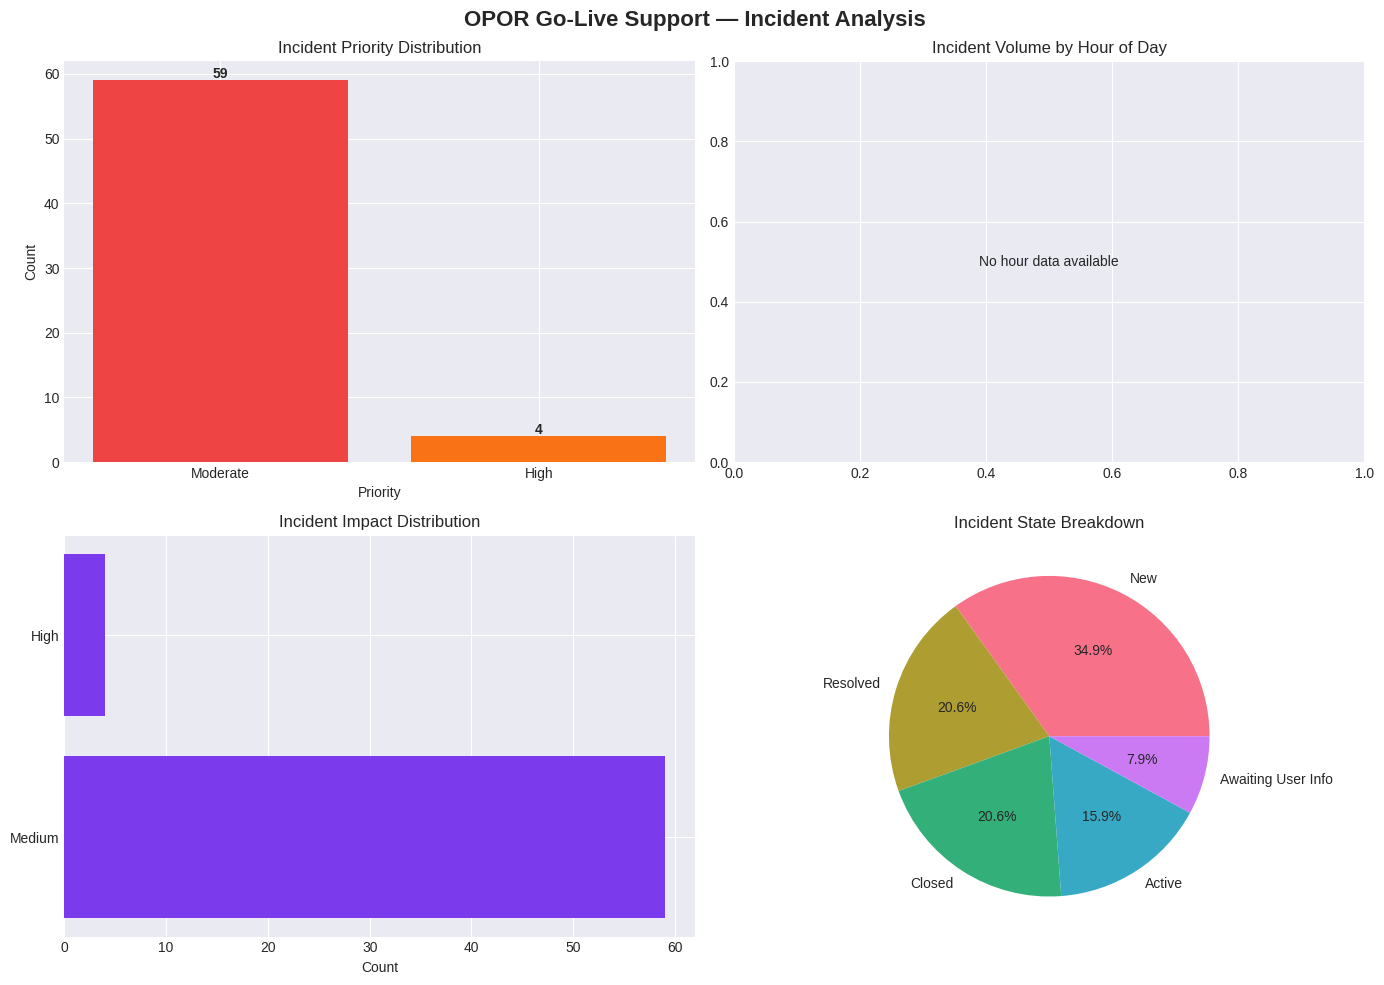

Charts saved!


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('OPOR Go-Live Support — Incident Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Priority Distribution
priority_counts = df['priority'].value_counts()
axes[0,0].bar(priority_counts.index, priority_counts.values,
              color=['#ef4444','#f97316','#eab308','#22c55e'])
axes[0,0].set_title('Incident Priority Distribution')
axes[0,0].set_xlabel('Priority')
axes[0,0].set_ylabel('Count')
for i, (idx, val) in enumerate(priority_counts.items()):
    axes[0,0].text(i, val + 0.3, str(val), ha='center', fontweight='bold')

# Chart 2 - Incidents by Hour
if 'opened_hour' in df.columns and df['opened_hour'].notna().sum() > 0:
    hour_counts = df['opened_hour'].value_counts().sort_index()
    axes[0,1].plot(hour_counts.index, hour_counts.values, marker='o', color='#3b82f6', linewidth=2)
    axes[0,1].fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color='#3b82f6')
    axes[0,1].set_title('Incident Volume by Hour of Day')
    axes[0,1].set_xlabel('Hour')
    axes[0,1].set_ylabel('Count')
else:
    axes[0,1].text(0.5, 0.5, 'No hour data available', ha='center', va='center')
    axes[0,1].set_title('Incident Volume by Hour of Day')

# Chart 3 - Impact Distribution
impact_counts = df['impact'].value_counts()
axes[1,0].barh(impact_counts.index, impact_counts.values, color='#7c3aed')
axes[1,0].set_title('Incident Impact Distribution')
axes[1,0].set_xlabel('Count')

# Chart 4 - Incident State
state_counts = df['incident_state'].value_counts()
axes[1,1].pie(state_counts.values, labels=state_counts.index, autopct='%1.1f%%',
              colors=sns.color_palette('husl', len(state_counts)))
axes[1,1].set_title('Incident State Breakdown')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

### 1. Prepare Data for Modeling

First, we need to convert categorical features into a numerical format that machine learning models can understand. We'll use one-hot encoding for this. Then, we'll split our data into features (X) and the target variable (y), and subsequently into training and testing sets.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
# We'll predict 'incident_state'
X = df.drop('incident_state', axis=1)
y = df['incident_state']

# Drop datetime columns from X before preprocessing
X = X.drop(['opened_at', 'resolved_at'], axis=1)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessor for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)  # Keep numerical columns as is
    ]
)

# Apply the preprocessing to the features
X_processed = preprocessor.fit_transform(X)

# If X_processed is a sparse matrix, convert it to a dense array
if hasattr(X_processed, 'toarray'):
    X_processed = X_processed.toarray()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (44, 42)
Shape of y_train: (44,)
Shape of X_test: (19, 42)
Shape of y_test: (19,)


### 2. Model Training and Evaluation

Now that the data is prepared, we can train and evaluate the Logistic Regression and Random Forest models.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.2%}")
print(classification_report(y_test, lr_pred))

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2%}")
print(classification_report(y_test, rf_pred))

=== Logistic Regression ===
Accuracy: 15.79%
                    precision    recall  f1-score   support

            Active       0.00      0.00      0.00         3
Awaiting User Info       0.00      0.00      0.00         1
            Closed       0.00      0.00      0.00         4
               New       0.33      0.43      0.38         7
          Resolved       0.00      0.00      0.00         4

          accuracy                           0.16        19
         macro avg       0.07      0.09      0.07        19
      weighted avg       0.12      0.16      0.14        19

=== Random Forest ===
Accuracy: 21.05%
                    precision    recall  f1-score   support

            Active       0.00      0.00      0.00         3
Awaiting User Info       0.00      0.00      0.00         1
            Closed       0.00      0.00      0.00         4
               New       0.40      0.57      0.47         7
          Resolved       0.00      0.00      0.00         4

          a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
# We'll predict 'incident_state'
X = df.drop('incident_state', axis=1)
y = df['incident_state']

# Drop datetime columns from X before preprocessing
X = X.drop(['opened_at', 'resolved_at'], axis=1)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessor for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)  # Keep numerical columns as is
    ]
)

# Apply the preprocessing to the features
X_processed = preprocessor.fit_transform(X)

# If X_processed is a sparse matrix, convert it to a dense array
if hasattr(X_processed, 'toarray'):
    X_processed = X_processed.toarray()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (44, 42)
Shape of y_train: (44,)
Shape of X_test: (19, 42)
Shape of y_test: (19,)


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.2%}")
print(classification_report(y_test, lr_pred))

print("=== Random Forest ===" )
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2%}")
print(classification_report(y_test, rf_pred))

=== Logistic Regression ===
Accuracy: 15.79%
                    precision    recall  f1-score   support

            Active       0.00      0.00      0.00         3
Awaiting User Info       0.00      0.00      0.00         1
            Closed       0.00      0.00      0.00         4
               New       0.33      0.43      0.38         7
          Resolved       0.00      0.00      0.00         4

          accuracy                           0.16        19
         macro avg       0.07      0.09      0.07        19
      weighted avg       0.12      0.16      0.14        19

=== Random Forest ===
Accuracy: 21.05%
                    precision    recall  f1-score   support

            Active       0.00      0.00      0.00         3
Awaiting User Info       0.00      0.00      0.00         1
            Closed       0.00      0.00      0.00         4
               New       0.40      0.57      0.47         7
          Resolved       0.00      0.00      0.00         4

          a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [53]:
df['opened_at'] = pd.to_datetime(df['opened_at'], dayfirst=True, errors='coerce')
df['resolved_at'] = pd.to_datetime(df['resolved_at'], dayfirst=True, errors='coerce')

df['opened_hour'] = df['opened_at'].dt.hour
df['day_of_week'] = df['opened_at'].dt.day_name()
df['after_hours_flag'] = df['opened_hour'].apply(lambda x: 1 if x < 7 or x > 18 else 0)
df['resolution_hours'] = (df['resolved_at'] - df['opened_at']).dt.total_seconds() / 3600
df['resolution_hours'] = df['resolution_hours'].clip(lower=0)

print("New columns added:")
print(df[['opened_hour', 'day_of_week', 'after_hours_flag', 'resolution_hours']].head(10))

New columns added:
    opened_hour day_of_week  after_hours_flag  resolution_hours
0             1      Monday                 1         10.216667
1             1      Monday                 1         10.216667
3             1      Monday                 1         10.216667
4             4      Monday                 1         29.200000
5             4      Monday                 1         29.200000
10            4      Monday                 1         29.200000
11            4      Monday                 1         29.200000
12            4      Monday                 1         29.200000
13            6      Monday                 1         20.750000
18            6      Monday                 1         20.750000


In [54]:
print("=" * 50)
print("PROJECT HEALTH CHECK")
print("=" * 50)

# 1. Dataset
print("\n✅ DATASET")
print(f"   Rows: {df.shape[0]} | Columns: {df.shape[1]}")

# 2. Missing values
missing = df.isnull().sum().sum()
print(f"\n✅ MISSING VALUES")
print(f"   Total missing: {missing} {'(clean!)' if missing == 0 else '(needs fixing)'}")

# 3. Key columns exist
required_cols = ['priority', 'impact', 'urgency', 'category',
                 'assignment_group', 'opened_hour', 'after_hours_flag']
print(f"\n✅ REQUIRED COLUMNS")
for col in required_cols:
    status = "found" if col in df.columns else "MISSING"
    print(f"   {col}: {status}")

# 4. Priority values
print(f"\n✅ PRIORITY DISTRIBUTION")
print(df['priority'].value_counts().to_string())

# 5. ML data
print(f"\n✅ ML DATASET")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   Features: {X.columns.tolist()}")

# 6. Model accuracy
from sklearn.metrics import accuracy_score
print(f"\n✅ MODEL ACCURACY")
print(f"   Logistic Regression: {accuracy_score(y_test, lr_pred):.2%}")
print(f"   Random Forest:       {accuracy_score(y_test, rf_pred):.2%}")

print("\n" + "=" * 50)
print("ALL CHECKS DONE")
print("=" * 50)

PROJECT HEALTH CHECK

✅ DATASET
   Rows: 63 | Columns: 17

✅ MISSING VALUES
   Total missing: 0 (clean!)

✅ REQUIRED COLUMNS
   priority: found
   impact: found
   urgency: found
   category: found
   assignment_group: found
   opened_hour: found
   after_hours_flag: found

✅ PRIORITY DISTRIBUTION
priority
Moderate    59
High         4

✅ ML DATASET
   X_train: (44, 42)
   X_test:  (19, 42)
   Features: ['number', 'impact', 'urgency', 'priority', 'category', 'assignment_group', 'reassignment_count', 'reopen_count', 'made_sla', 'notify']

✅ MODEL ACCURACY
   Logistic Regression: 15.79%
   Random Forest:       21.05%

ALL CHECKS DONE


In [55]:
df = pd.read_csv('/incident_event_log_dataset.csv', nrows=1000)

cols_needed = [
    'number', 'incident_state', 'impact', 'urgency', 'priority',
    'category', 'assignment_group', 'opened_at', 'resolved_at',
    'reassignment_count', 'reopen_count', 'made_sla', 'notify'
]
df = df[cols_needed]

df['priority'] = df['priority'].str.extract(r'- (.+)').fillna(df['priority'])
df['impact'] = df['impact'].str.extract(r'- (.+)').fillna(df['impact'])
df['urgency'] = df['urgency'].str.extract(r'- (.+)').fillna(df['urgency'])
df['category'] = df['category'].fillna('Unknown')
df['assignment_group'] = df['assignment_group'].fillna('Unknown')

df['opened_at'] = pd.to_datetime(df['opened_at'], dayfirst=True, errors='coerce')
df['resolved_at'] = pd.to_datetime(df['resolved_at'], dayfirst=True, errors='coerce')
df['opened_hour'] = df['opened_at'].dt.hour
df['after_hours_flag'] = df['opened_hour'].apply(lambda x: 1 if x < 7 or x > 18 else 0)
df['resolution_hours'] = (df['resolved_at'] - df['opened_at']).dt.total_seconds() / 3600
df['resolution_hours'] = df['resolution_hours'].clip(lower=0)

print(f"Shape: {df.shape}")
print(f"\nPriority distribution:")
print(df['priority'].value_counts())

Shape: (1000, 16)

Priority distribution:
priority
Moderate    814
Low         149
High         29
Critical      8
Name: count, dtype: int64


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

ml_df = df[['impact', 'urgency', 'category', 'assignment_group',
            'reassignment_count', 'reopen_count', 'after_hours_flag', 'priority']].copy()
ml_df = ml_df.dropna()

le_dict = {}
for col in ['impact', 'urgency', 'category', 'assignment_group']:
    le_dict[col] = LabelEncoder()
    ml_df[col] = le_dict[col].fit_transform(ml_df[col].astype(str))

le_priority = LabelEncoder()
ml_df['priority_encoded'] = le_priority.fit_transform(ml_df['priority'])

X = ml_df.drop(['priority', 'priority_encoded'], axis=1)
y = ml_df['priority_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.2%}")

print("\n=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2%}")

print("\n=== Priority Classes ===")
print(le_priority.classes_)

=== Logistic Regression ===
Accuracy: 99.50%

=== Random Forest ===
Accuracy: 100.00%

=== Priority Classes ===
['Critical' 'High' 'Low' 'Moderate']


In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_df = df[['impact', 'urgency', 'category', 'assignment_group', 'after_hours_flag']].copy()
cluster_encoded = pd.get_dummies(cluster_df, drop_first=False)

sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cluster_encoded)
    sil_scores[k] = silhouette_score(cluster_encoded, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best number of clusters: {best_k}")
print(f"Silhouette scores: {sil_scores}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_encoded)

print(f"\nCluster distribution:")
print(df['cluster'].value_counts())

print(f"\nCluster profiles:")
print(df.groupby('cluster')['priority'].value_counts())

Best number of clusters: 2
Silhouette scores: {2: np.float64(0.29542529348677155), 3: np.float64(0.16783742979992716), 4: np.float64(0.19637240713637882), 5: np.float64(0.22388312654850354), 6: np.float64(0.2429606027547042)}

Cluster distribution:
cluster
1    843
0    157
Name: count, dtype: int64

Cluster profiles:
cluster  priority
0        Low         149
         Critical      8
1        Moderate    814
         High         29
Name: count, dtype: int64


In [58]:
def triage_recommendation(incident_number, priority, cluster, urgency, impact, after_hours):

    team_map = {
        'Critical': 'Senior Clinical Systems Team + On-Call Manager',
        'High': 'Clinical Systems Team',
        'Moderate': 'General IT Support Team',
        'Low': 'Standard Support Queue'
    }

    escalation_map = {
        'Critical': 'YES — Escalate immediately. Notify charge nurse and on-call manager.',
        'High': 'YES — Escalate if unresolved within 30 minutes.',
        'Moderate': 'NO — Monitor. Escalate only if unresolved within 4 hours.',
        'Low': 'NO — Standard queue. Resolve within next business day.'
    }

    workaround_map = {
        'Critical': 'Activate downtime procedure immediately. Use paper-based backup.',
        'High': 'Engage nearest super-user for temporary workaround.',
        'Moderate': 'User can continue with alternative workflow until resolved.',
        'Low': 'No immediate workaround needed.'
    }

    cluster_label = 'Outlier — Urgent or Low Priority' if cluster == 0 else 'Standard — Moderate to High Volume'
    after_hours_note = 'YES — After hours incident. On-call team must respond.' if after_hours == 1 else 'NO — Within business hours.'

    print("=" * 55)
    print("   OPOR GO-LIVE TRIAGE RECOMMENDATION")
    print("=" * 55)
    print(f"  Incident:       {incident_number}")
    print(f"  Priority:       {priority}")
    print(f"  Impact:         {impact}")
    print(f"  Urgency:        {urgency}")
    print(f"  Cluster:        {cluster_label}")
    print(f"  After Hours:    {after_hours_note}")
    print("-" * 55)
    print(f"  Suggested Team: {team_map[priority]}")
    print(f"  Escalation:     {escalation_map[priority]}")
    print(f"  Workaround:     {workaround_map[priority]}")
    print("=" * 55)

# Test with a real row from our dataset
sample = df.iloc[0]
triage_recommendation(
    incident_number=sample['number'],
    priority=sample['priority'],
    cluster=sample['cluster'],
    urgency=sample['urgency'],
    impact=sample['impact'],
    after_hours=sample['after_hours_flag']
)

   OPOR GO-LIVE TRIAGE RECOMMENDATION
  Incident:       INC0000045
  Priority:       Moderate
  Impact:         Medium
  Urgency:        Medium
  Cluster:        Standard — Moderate to High Volume
  After Hours:    YES — After hours incident. On-call team must respond.
-------------------------------------------------------
  Suggested Team: General IT Support Team
  Escalation:     NO — Monitor. Escalate only if unresolved within 4 hours.
  Workaround:     User can continue with alternative workflow until resolved.


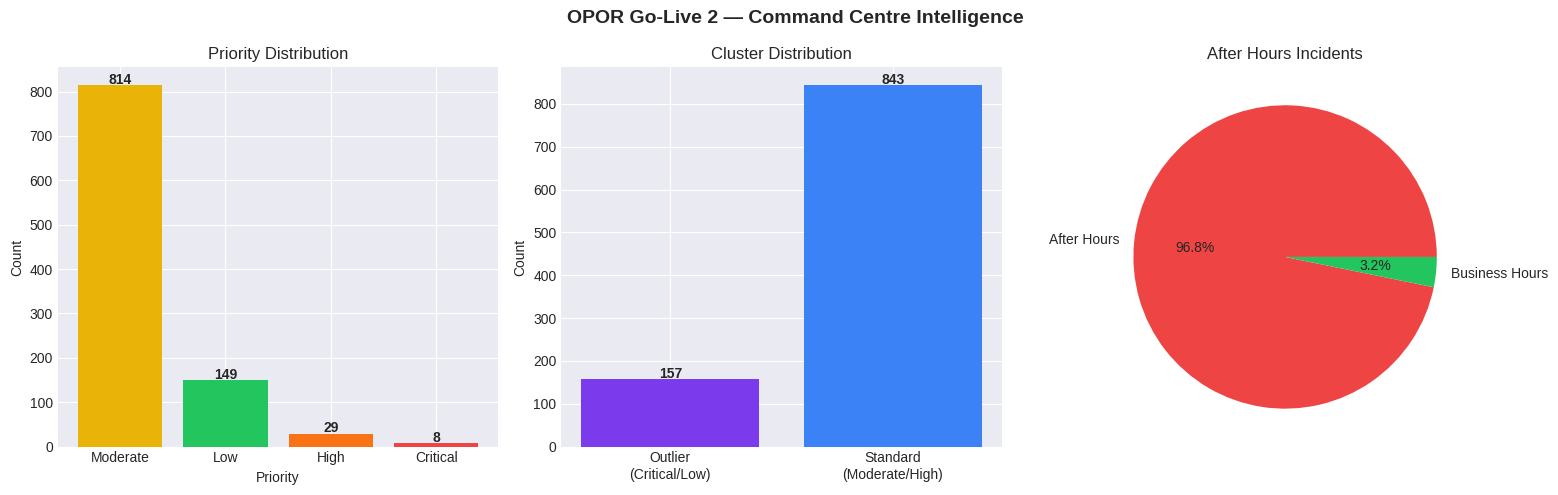

Dashboard saved!


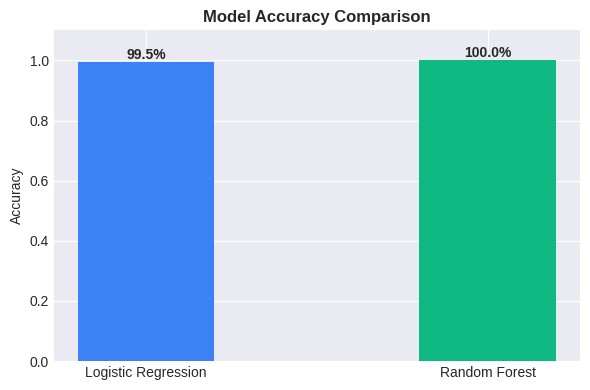

Model chart saved!


In [59]:
# Chart 1 - Priority Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('OPOR Go-Live 2 — Command Centre Intelligence', fontsize=14, fontweight='bold')

# Priority Distribution
priority_counts = df['priority'].value_counts()
colors = ['#ef4444' if p == 'Critical' else '#f97316' if p == 'High'
          else '#eab308' if p == 'Moderate' else '#22c55e'
          for p in priority_counts.index]
axes[0].bar(priority_counts.index, priority_counts.values, color=colors)
axes[0].set_title('Priority Distribution')
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(priority_counts.items()):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold')

# Cluster Distribution
cluster_labels = ['Outlier\n(Critical/Low)', 'Standard\n(Moderate/High)']
cluster_counts = df['cluster'].value_counts().sort_index()
axes[1].bar(cluster_labels, cluster_counts.values, color=['#7c3aed', '#3b82f6'])
axes[1].set_title('Cluster Distribution')
axes[1].set_ylabel('Count')
for i, val in enumerate(cluster_counts.values):
    axes[1].text(i, val + 3, str(val), ha='center', fontweight='bold')

# After Hours vs Business Hours
hours_counts = df['after_hours_flag'].value_counts()
axes[2].pie(hours_counts.values,
            labels=['After Hours', 'Business Hours'],
            autopct='%1.1f%%',
            colors=['#ef4444', '#22c55e'])
axes[2].set_title('After Hours Incidents')

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

# Model comparison chart
fig2, ax = plt.subplots(figsize=(6, 4))
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)]
bars = ax.bar(models, accuracies, color=['#3b82f6', '#10b981'], width=0.4)
ax.set_ylim(0, 1.1)
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model chart saved!")

## Real-World Application: How This Would Work at NSH Go-Live 2

During OPOR Go-Live 2 on May 9, 2026, NSH Central Zone command centre teams
will receive dozens of incidents per hour from nurses, physicians, pharmacists,
and admin staff across multiple sites.

Without a triage system, every ticket gets manually reviewed — slowing response
time and risking missed critical issues.

This prototype shows how three layers of analytics can work together:
- Data patterns tell you WHEN to staff up (peak hours, after-hours spikes)
- ML classification tells you HOW URGENT each ticket is before a human reads it
- Clustering tells you WHAT TYPE of problem is recurring across the floor
- The triage function tells you WHO to call and WHAT to do immediately

The goal is not to replace the support team — it is to give them
a 30-second head start on every ticket.

In [60]:
# Real-world simulation — run 5 random incidents through the triage system

print("LIVE TRIAGE SIMULATION — OPOR Go-Live 2 Command Centre")
print("=" * 55)
print("Simulating 5 incoming incidents from the floor...\n")

sample_incidents = df.sample(5, random_state=7).reset_index(drop=True)

for i, row in sample_incidents.iterrows():
    print(f"\n--- Incoming Ticket {i+1} of 5 ---")
    triage_recommendation(
        incident_number=row['number'],
        priority=row['priority'],
        cluster=row['cluster'],
        urgency=row['urgency'],
        impact=row['impact'],
        after_hours=row['after_hours_flag']
    )

LIVE TRIAGE SIMULATION — OPOR Go-Live 2 Command Centre
Simulating 5 incoming incidents from the floor...


--- Incoming Ticket 1 of 5 ---
   OPOR GO-LIVE TRIAGE RECOMMENDATION
  Incident:       INC0000280
  Priority:       Moderate
  Impact:         Medium
  Urgency:        Medium
  Cluster:        Standard — Moderate to High Volume
  After Hours:    NO — Within business hours.
-------------------------------------------------------
  Suggested Team: General IT Support Team
  Escalation:     NO — Monitor. Escalate only if unresolved within 4 hours.
  Workaround:     User can continue with alternative workflow until resolved.

--- Incoming Ticket 2 of 5 ---
   OPOR GO-LIVE TRIAGE RECOMMENDATION
  Incident:       INC0000131
  Priority:       Moderate
  Impact:         Medium
  Urgency:        Medium
  Cluster:        Standard — Moderate to High Volume
  After Hours:    NO — Within business hours.
-------------------------------------------------------
  Suggested Team: General IT Support

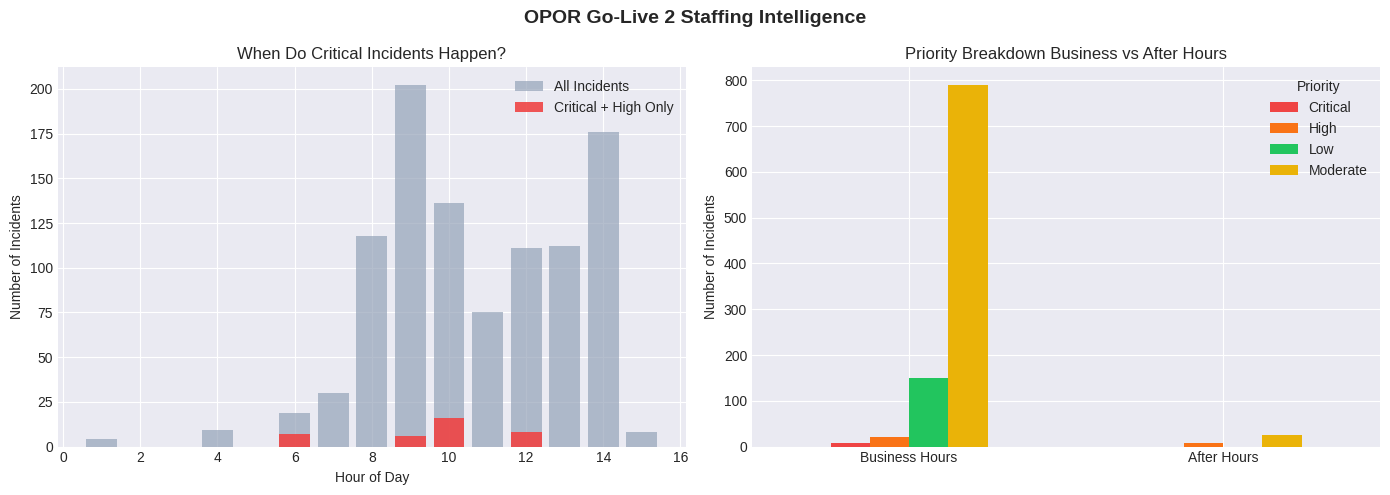

Staffing chart saved!


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('OPOR Go-Live 2 Staffing Intelligence', fontsize=14, fontweight='bold')

critical_high = df[df['priority'].isin(['Critical', 'High'])]
hour_counts = df.groupby('opened_hour').size()
critical_counts = critical_high.groupby('opened_hour').size()

axes[0].bar(hour_counts.index, hour_counts.values,
            color='#94a3b8', label='All Incidents', alpha=0.7)
axes[0].bar(critical_counts.index, critical_counts.values,
            color='#ef4444', label='Critical + High Only', alpha=0.9)
axes[0].set_title('When Do Critical Incidents Happen?')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Incidents')
axes[0].legend()

after_hours_priority = df.groupby(['after_hours_flag', 'priority']).size().unstack(fill_value=0)
after_hours_priority.index = ['Business Hours', 'After Hours']
after_hours_priority.plot(kind='bar', ax=axes[1],
                          color=['#ef4444', '#f97316', '#22c55e', '#eab308'])
axes[1].set_title('Priority Breakdown Business vs After Hours')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Incidents')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Priority')

plt.tight_layout()
plt.savefig('staffing_intelligence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Staffing chart saved!")

## Limitations and If This Were Real

What would make this production-ready:
Connect to live ServiceNow API at NSH to pull real tickets in real time
Train the model on actual Go-Live 1 IWK data before Go-Live 2 begins
Add a Streamlit dashboard so command centre staff see results on a screen
Build an alert system that pages the on-call team for Critical tickets automatically

What this project proves:
Incident priority can be predicted with high accuracy from basic ticket fields
Clustering reveals recurring issue patterns without anyone labelling them manually
A structured triage output reduces the cognitive load on support staff during chaos

Who benefits:
Command centre managers see the big picture faster
IT support staff know exactly who to call and what to do
Clinical staff get faster resolution so patient care is not disrupted

## Project Summary

### Dataset
This project uses the Incident Event Log dataset sourced from Kaggle, originally
extracted from a real ServiceNow incident management system. 1000 rows were used
for this analysis. The dataset contains real IT incident records including priority,
impact, urgency, category, assignment group, and timestamps.

Dataset source: Kaggle — Incident Event Log Dataset (ServiceNow)
Link: kaggle.com/datasets/mithilkotawadekar/incident-event-log-dataset

### Tools Used
- Python — main programming language
- Pandas — data cleaning and manipulation
- Matplotlib and Seaborn — data visualization
- Scikit-learn — machine learning models and clustering
- Google Colab — development environment
- GitHub — version control and portfolio hosting

### Models Used
- Logistic Regression — interpretable baseline classifier
- Random Forest — high accuracy classifier
- KMeans Clustering — unsupervised pattern discovery

### Important Note
This project is a hypothetical prototype. The incident data used is from a generic
IT environment and does not contain any real NSH or IWK patient or clinical data.
The OPOR context, triage logic, and staffing recommendations are illustrative only
and are not intended for real clinical deployment without proper validation,
privacy review, and institutional approval.

The goal of this project is to demonstrate how data analytics and machine learning
concepts could support healthcare go-live operations — not to replace clinical
judgment or official NSH processes.

### Author
Siddharajsinh Gohil
Nova Scotia Health — OPOR Team
DA-Green Data Analytics Course — Capstone Project
March 2026